In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("HR_comma_sep.csv")
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [8]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

The dataset contains 14,999 employee records and 10 features.
Data quality checks were performed using df.isnull().sum(), and no missing values were found.
The dataset contains both numerical and categorical features, such as department and salary.

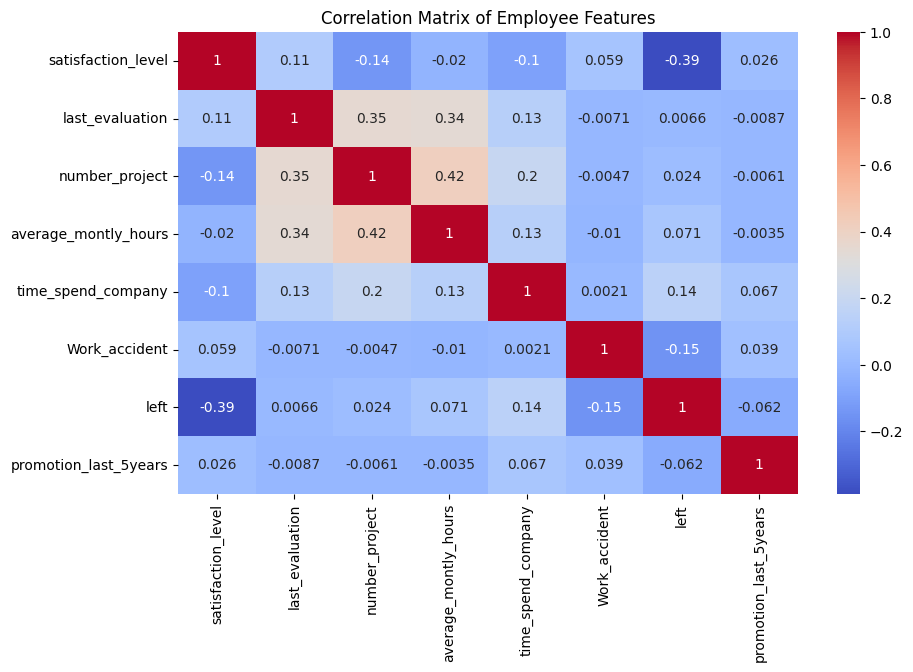

In [9]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix of Employee Features")

plt.show()

In [10]:
cluster_data = df[['satisfaction_level','last_evaluation','left']]
cluster_data.head()

,satisfaction_level,last_evaluation,left
0,0.38,0.53,1
1,0.80,0.86,1
2,0.11,0.88,1
3,0.72,0.87,1
4,0.37,0.52,1


In [11]:
left_emp = cluster_data[cluster_data['left'] == 1].copy()
left_emp.head()
left_emp.shape

(3571, 3)

In [12]:
X = left_emp[['satisfaction_level','last_evaluation']]

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=123, n_init=10)

left_emp['cluster'] = kmeans.fit_predict(X)

In [13]:
left_emp.head()

,satisfaction_level,last_evaluation,left,cluster
0,0.38,0.53,1,1
1,0.80,0.86,1,2
2,0.11,0.88,1,0
3,0.72,0.87,1,2
4,0.37,0.52,1,1


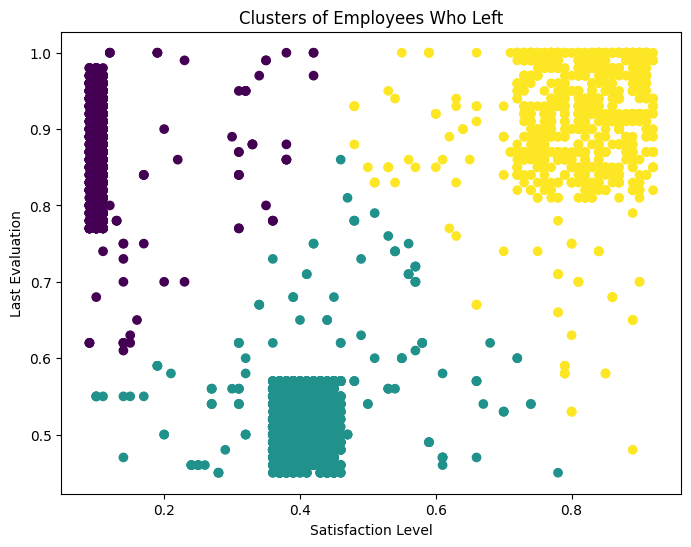

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(left_emp['satisfaction_level'],
            left_emp['last_evaluation'],
            c=left_emp['cluster'],
            cmap='viridis')

plt.xlabel("Satisfaction Level")
plt.ylabel("Last Evaluation")
plt.title("Clusters of Employees Who Left")

plt.show()

In [15]:
df['left'].value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

In [16]:
cat_cols = ['sales', 'salary']
num_cols = df.drop(columns=cat_cols)
cat_encoded = pd.get_dummies(df[cat_cols], drop_first=True)
print(cat_encoded)


       sales_RandD  sales_accounting  sales_hr  sales_management  \
0            False             False     False             False   
1            False             False     False             False   
2            False             False     False             False   
3            False             False     False             False   
4            False             False     False             False   
...            ...               ...       ...               ...   
14994        False             False     False             False   
14995        False             False     False             False   
14996        False             False     False             False   
14997        False             False     False             False   
14998        False             False     False             False   

       sales_marketing  sales_product_mng  sales_sales  sales_support  \
0                False              False         True          False   
1                False              F

In [17]:
df_processed = pd.concat([num_cols, cat_encoded], axis=1)
df_processed.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


In [18]:
X = df_processed.drop('left', axis=1)
y = df_processed['left']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123,
    stratify=y
)
X_train.shape
X_test.shape

(3000, 18)

In [20]:
y_train.value_counts()

left
0    9142
1    2857
Name: count, dtype: int64

In [21]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=123)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
y_train_sm.value_counts()

left
0    9142
1    9142
Name: count, dtype: int64

In [22]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_sm, y_train_sm)
y_pred_log = log_model.predict(X_test)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.91      0.77      0.83      2286
           1       0.51      0.74      0.60       714

    accuracy                           0.77      3000
   macro avg       0.71      0.76      0.72      3000
weighted avg       0.81      0.77      0.78      3000



In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=123)

rf_model.fit(X_train_sm, y_train_sm)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.98      0.98      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



The Random Forest classifier significantly outperformed the Logistic Regression model. It achieved an accuracy of 99% with both precision and recall close to 0.98–0.99. This indicates that the model is highly effective at predicting employee turnover. Random Forest performs better because it captures complex relationships between features such as satisfaction level, number of projects, and working hours.


In [24]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=123)

gb_model.fit(X_train_sm, y_train_sm)

y_pred_gb = gb_model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2286
           1       0.92      0.93      0.93       714

    accuracy                           0.97      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.97      0.97      0.97      3000



Three models were trained and evaluated: Logistic Regression, Random Forest, and Gradient Boosting. Among these models, the Random Forest classifier achieved the highest performance with an accuracy of 99% and a recall of 98% for predicting employee turnover. This indicates that Random Forest is the most effective model for predicting employee attrition in this dataset.

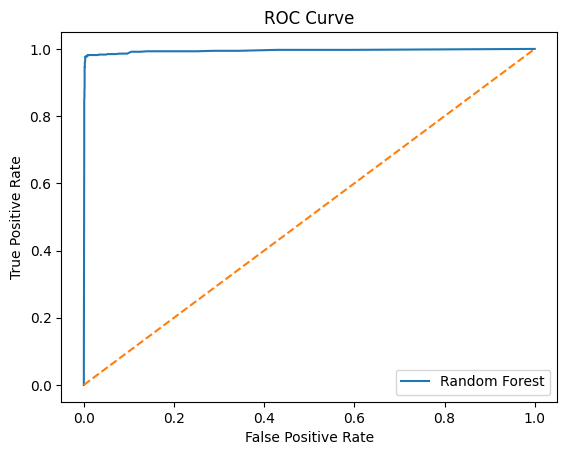

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# probability predictions
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# plot ROC
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [26]:
roc_auc_score(y_test, y_prob_rf)

0.9946324111446854

The ROC curve was used to evaluate the performance of the Random Forest model. The curve is very close to the top-left corner, indicating a high true positive rate and a low false positive rate. This demonstrates that the model is highly effective at distinguishing between employees who will leave and those who will stay. The AUC score is close to 0.99, which indicates excellent predictive performance.

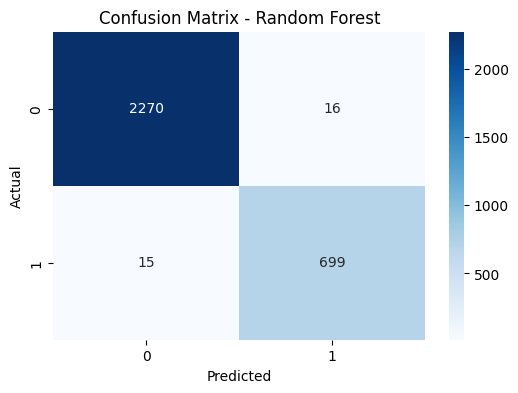

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [29]:
turnover_prob = rf_model.predict_proba(X_test)[:,1]
results = X_test.copy()
results['Turnover_Probability'] = turnover_prob

results.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium,Turnover_Probability
10627,0.98,0.77,3,191,2,0,0,False,False,False,False,False,False,True,False,False,False,True,0.00
2703,0.76,0.93,3,271,5,0,0,False,False,True,False,False,False,False,False,False,True,False,0.54
6059,0.70,0.93,3,185,4,0,0,False,True,False,False,False,False,False,False,False,False,True,0.05
3258,0.48,0.61,3,223,3,1,0,False,False,False,False,False,False,False,True,False,False,True,0.01
4565,0.57,0.90,3,144,2,0,0,False,False,False,False,False,False,False,False,False,False,True,0.00


In [30]:
def risk_zone(prob):
    
    if prob < 0.20:
        return "Safe Zone (Green)"
    
    elif prob < 0.60:
        return "Low Risk (Yellow)"
    
    elif prob < 0.90:
        return "Medium Risk (Orange)"
    
    else:
        return "High Risk (Red)"


results['Risk_Zone'] = results['Turnover_Probability'].apply(risk_zone)

results.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium,Turnover_Probability,Risk_Zone
10627,0.98,0.77,3,191,2,0,0,False,False,False,False,False,False,True,False,False,False,True,0.00,Safe Zone (Green)
2703,0.76,0.93,3,271,5,0,0,False,False,True,False,False,False,False,False,False,True,False,0.54,Low Risk (Yellow)
6059,0.70,0.93,3,185,4,0,0,False,True,False,False,False,False,False,False,False,False,True,0.05,Safe Zone (Green)
3258,0.48,0.61,3,223,3,1,0,False,False,False,False,False,False,False,True,False,False,True,0.01,Safe Zone (Green)
4565,0.57,0.90,3,144,2,0,0,False,False,False,False,False,False,False,False,False,False,True,0.00,Safe Zone (Green)


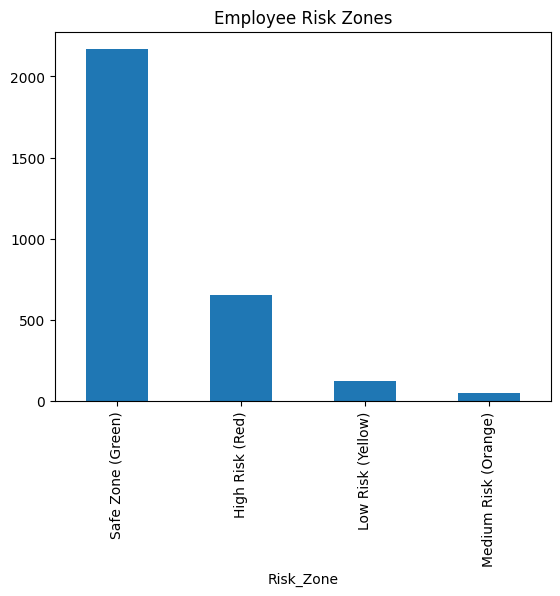

In [31]:
results['Risk_Zone'].value_counts().plot(kind='bar')

plt.title("Employee Risk Zones")
plt.show()

Employees were categorized into four risk zones based on the predicted probability of turnover using the Random Forest model. Employees in the Safe Zone have a probability of leaving below 20% and require minimal intervention. Employees in the Low Risk Zone should be monitored and provided career development opportunities. Employees in the Medium Risk Zone require proactive retention strategies such as workload balancing and salary review. Employees in the High Risk Zone require immediate HR attention to prevent potential attrition.